In [3]:
from google.colab import files
import pandas as pd
import numpy as np


uploaded = files.upload()


df = pd.read_excel('Transportation & Logistics Tracking Dataset.xlsx', sheet_name='Primary Data')
print("Đã nạp dữ liệu thành công! Kích thước dữ liệu:", df.shape)

Saving Transportation & Logistics Tracking Dataset.xlsx to Transportation & Logistics Tracking Dataset (1).xlsx
Đã nạp dữ liệu thành công! Kích thước dữ liệu: (3585, 28)


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Đọc tệp dữ liệu từ bộ nhớ tạm của Colab
file_name = 'Transportation & Logistics Tracking Dataset (1).xlsx'
df = pd.read_excel(file_name, sheet_name='Primary Data')

# 2. TỰ ĐỘNG TẠO CỘT Delivery_Duration_Hours NẾU THIẾU
if 'Delivery_Duration_Hours' not in df.columns:
    print("💡 Tự động tính toán lại cột 'Delivery_Duration_Hours' từ mốc thời gian...")
    df['Trip Start Date'] = pd.to_datetime(df['Trip Start Date'])
    df['Trip End Date'] = pd.to_datetime(df['Trip End Date'])
    df['Delivery_Duration_Hours'] = (df['Trip End Date'] - df['Trip Start Date']).dt.total_seconds() / 3600

# 3. TỰ ĐỘNG TẠO CỘT MỤC TIÊU Is_Delayed NẾU THIẾU (Dựa trên cột Ontime gốc)
if 'Is_Delayed' not in df.columns:
    print("💡 Tự động tạo cột biến mục tiêu 'Is_Delayed' từ cột dữ liệu chữ 'Ontime'...")
    # Nếu Ontime là "Yes" (đúng hạn) thì Is_Delayed = 0, ngược lại (trễ chuyến) thì Is_Delayed = 1
    df['Is_Delayed'] = np.where(df['Ontime'].astype(str).str.strip().str.lower() == 'yes', 0, 1)

# 4. Xác định danh sách các biến đặc trưng
target = 'Is_Delayed'
numerical_features = ['Transportation Distance (KM)', 'Delivery_Duration_Hours']
categorical_features = ['Supplier Name', 'Vehicle Type', 'Shipment Type']

# Loại bỏ các dòng trống (NaN) nếu có trong các biến phối hợp để tránh lỗi thuật toán
df = df.dropna(subset=numerical_features + categorical_features + [target])

X = df[numerical_features + categorical_features]
y = df[target]

# 5. Thiết lập cấu trúc tiền xử lý dữ liệu tự động (Pipeline Preprocessing)
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Thực hiện chia tập dữ liệu thành 80% Train và 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n[OK] Kích thước tập huấn luyện (Train set): {X_train.shape}")
print(f"[OK] Kích thước tập kiểm tra (Test set): {X_test.shape}")

# 7. Huấn luyện mô hình cơ sở Logistic Regression
model_lr = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

# 8. Xuất báo cáo kết quả đánh giá mô hình học máy
print("\n" + "="*20 + " KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION " + "="*20)
print(f"Accuracy Score (Độ chính xác tổng thể): {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix (Ma trận nhầm lẫn):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report (Báo cáo chi tiết hiệu năng phân lớp):")
print(classification_report(y_test, y_pred))

💡 Tự động tính toán lại cột 'Delivery_Duration_Hours' từ mốc thời gian...
💡 Tự động tạo cột biến mục tiêu 'Is_Delayed' từ cột dữ liệu chữ 'Ontime'...

[OK] Kích thước tập huấn luyện (Train set): (2138, 5)
[OK] Kích thước tập kiểm tra (Test set): (535, 5)

==================== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION ====================
Accuracy Score (Độ chính xác tổng thể): 0.8056

Confusion Matrix (Ma trận nhầm lẫn):
[[ 31  96]
 [  8 400]]

Classification Report (Báo cáo chi tiết hiệu năng phân lớp):
              precision    recall  f1-score   support

           0       0.79      0.24      0.37       127
           1       0.81      0.98      0.88       408

    accuracy                           0.81       535
   macro avg       0.80      0.61      0.63       535
weighted avg       0.80      0.81      0.76       535



In [7]:
from sklearn.ensemble import RandomForestClassifier

# 1. Khởi tạo cấu hình thuật toán Random Forest nâng cao
model_rf = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))])

# 2. Huấn luyện mô hình Random Forest trên tập dữ liệu cũ
model_rf.fit(X_train, y_train)

# 3. Dự đoán trên tập dữ liệu kiểm tra
y_pred_rf = model_rf.predict(X_test)

# 4. Xuất kết quả đánh giá hiệu năng
print("="*20 + " KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST " + "="*20)
print(f"Accuracy Score (Độ chính xác tổng thể): {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Confusion Matrix (Ma trận nhầm lẫn):")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report (Báo cáo chi tiết các phân lớp):")
print(classification_report(y_test, y_pred_rf))

==================== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ====================
Accuracy Score (Độ chính xác tổng thể): 0.8579

Confusion Matrix (Ma trận nhầm lẫn):
[[ 86  41]
 [ 35 373]]

Classification Report (Báo cáo chi tiết các phân lớp):
              precision    recall  f1-score   support

           0       0.71      0.68      0.69       127
           1       0.90      0.91      0.91       408

    accuracy                           0.86       535
   macro avg       0.81      0.80      0.80       535
weighted avg       0.86      0.86      0.86       535



/tmp/ipykernel_5153/3460990462.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette='viridis')


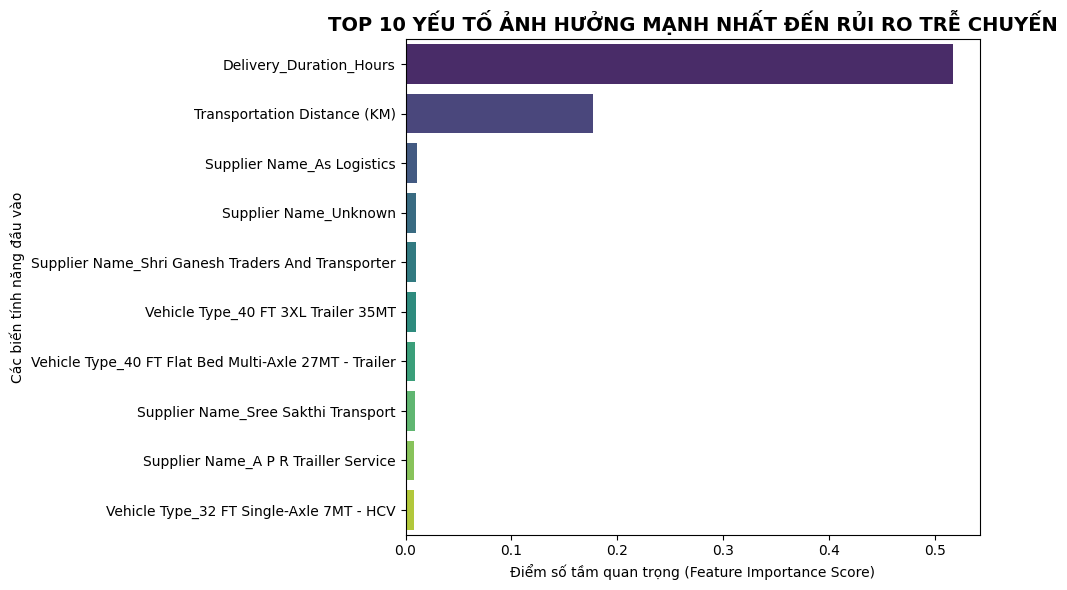

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trích xuất tên các cột sau khi đã qua bước mã hóa một-hot (One-Hot Encoding)
cat_encoder = model_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))
all_features = numerical_features + encoded_cat_features

# 2. Lấy điểm số tầm quan trọng của các biến từ mô hình Random Forest
importances = model_rf.named_steps['classifier'].feature_importances_

# 3. Sắp xếp và chọn ra top 10 yếu tố ảnh hưởng mạnh nhất
indices = np.argsort(importances)[::-1][:10]
top_features = [all_features[i] for i in indices]
top_importances = importances[indices]

# 4. Vẽ biểu đồ đồ họa trực quan
plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features, palette='viridis')
plt.title('TOP 10 YẾU TỐ ẢNH HƯỞNG MẠNH NHẤT ĐẾN RỦI RO TRỄ CHUYẾN', fontsize=14, fontweight='bold')
plt.xlabel('Điểm số tầm quan trọng (Feature Importance Score)')
plt.ylabel('Các biến tính năng đầu vào')
plt.tight_layout()
plt.show()